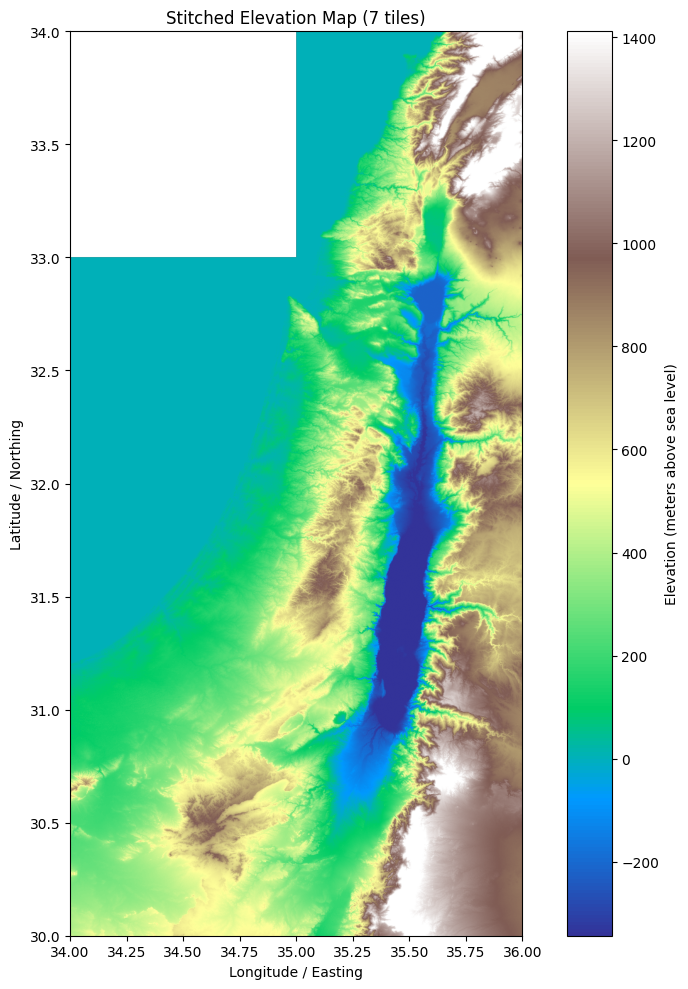

In [2]:
import rasterio
from rasterio.merge import merge
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# Directory containing the .hgt files
data_dir = Path("../../data/SRTMGL1_003-20260321_112154")
hgt_files = list(data_dir.glob("*.hgt"))

src_files_to_mosaic = []
try:
    for fp in hgt_files:
        src = rasterio.open(fp)
        src_files_to_mosaic.append(src)
    
    # Merge and get first band
    mosaic, out_trans = merge(src_files_to_mosaic)
    elevation = mosaic[0]
    height, width = elevation.shape
    
    # geographic bounds
    left, top = out_trans * (0, 0)
    right, bottom = out_trans * (width, height)
    extent = [left, right, bottom, top]

    # Downsample
    step = 10
    # We must convert to floats before we can use np.nan!
    display_elevation = elevation[::step, ::step].astype(float)
    
    # ------ THE COLOR FIX ------
    # Detect the bad "no-data" constant (-32768) and overwrite it with NaN
    nodata = src_files_to_mosaic[0].nodata if src_files_to_mosaic[0].nodata is not None else -32768
    display_elevation[display_elevation <= nodata] = np.nan
    
    # Calculate vmin/vmax ignoring the NaNs
    valid_data = display_elevation[~np.isnan(display_elevation)]
    vmin, vmax = np.percentile(valid_data, [2, 98])
    # ---------------------------

    # Set up plot
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Matplotlib will organically treat 'np.nan' as transparent/white space
    img = ax.imshow(display_elevation, cmap='terrain', extent=extent, vmin=vmin, vmax=vmax)
    
    cbar = plt.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Elevation (meters above sea level)')
    
    ax.set_title(f"Stitched Elevation Map ({len(hgt_files)} tiles)")
    ax.set_xlabel('Longitude / Easting')
    ax.set_ylabel('Latitude / Northing')
    
    plt.tight_layout()
    plt.show()

finally:
    for src in src_files_to_mosaic:
        src.close()
